# TabPFNによる回帰

[公式サンプル](https://github.com/PriorLabs/TabPFN/blob/main/examples/tabpfn_for_regression.py)と同じ糖尿病データを使う。初回の`fit`時にはモデルがダウンロードされ、ライセンス同意のためPrior Labsへのログインを求められる場合がある。

In [1]:
!pip install -q -U tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor

from tabpfn.constants import ModelVersion

In [3]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)
print(X_train.shape, X_test.shape)

(296, 10) (146, 10)


In [4]:
#reg = TabPFNRegressor()
reg = TabPFNRegressor.create_default_for_version(ModelVersion.V2)

reg.fit(X_train, y_train)
tabpfn_predictions = reg.predict(X_test)

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
linear_predictions = linear_reg.predict(X_test)

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

In [5]:
for name, predictions in {
    "TabPFN": tabpfn_predictions,
    "LinearRegression": linear_predictions,
}.items():
    print(name)
    print("  MSE:", mean_squared_error(y_test, predictions))
    print("  MAE:", mean_absolute_error(y_test, predictions))
    print("  R²:", r2_score(y_test, predictions))

TabPFN
  MSE: 2689.568260769841
  MAE: 41.00204535706403
  R²: 0.5326764893115477
LinearRegression
  MSE: 2817.8082972215857
  MAE: 41.96450967184069
  R²: 0.510394257282125


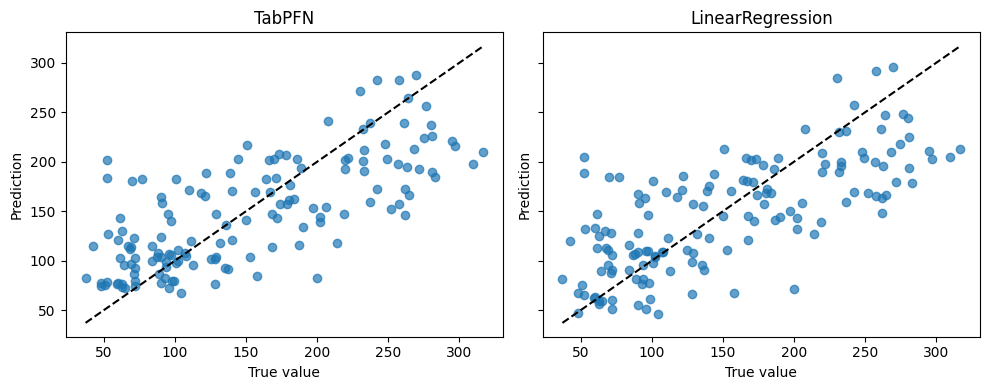

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
low, high = y_test.min(), y_test.max()

for ax, name, predictions in zip(
    axes, ["TabPFN", "LinearRegression"],
    [tabpfn_predictions, linear_predictions],
):
    ax.scatter(y_test, predictions, alpha=0.7)
    ax.plot([low, high], [low, high], "--", color="black")
    ax.set(title=name, xlabel="True value", ylabel="Prediction")

plt.tight_layout()
plt.show()